# Covariance vs exact_attr and Δy(0.1) for Improving Adversarial Transferability via Neuron Attribution-Based Attacks

Этот ноутбук является отдельной, более узкой версией `Experiments/ImprovingAdvTransViaAttrib_covariance.ipynb`.

Здесь анализируются две пары величин на раннем участке пути:
- `covariance[0, 0.1]` vs `exact_attr[0, 0.1]`
- `covariance[0, 0.1]` vs `Δy(0.1)`

Что именно сравнивается:
- `covariance[0, 0.1]`: ковариация считается только на раннем отрезке `alpha ∈ [0, 0.1]`.
- `exact_attr[0, 0.1]`: точный сегментный attribution `mean[a_m * b_m]` на том же отрезке `alpha ∈ [0, 0.1]`.
- `Δy(0.1)`: точная разность активаций `y(x_{alpha=0.1}) - y(x_0)`.

Для каждой пары строятся сравнения в трех режимах:
- `abs`: сравнение по модулю.
- `positive`: только положительные хвосты.
- `negative`: модули отрицательных хвостов.

Дополнительно выводятся численные метрики, чтобы связь была видна не только по одной smoothed-кривой:
- Pearson / Spearman на raw-score и Pearson после `log1p`
- overlap top-k множеств
- capture of reference mass by covariance-top neurons
- отношение `capture / oracle-capture`
- shape similarity ранговых кривых (`cosine`, `spearman`) в raw и smoothed виде


### Импорты и базовая конфигурация
Подключаем библиотеки, включаем градиенты и определяем устройство для вычислений.


In [1]:
import math
import gc

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from torch.func import jvp

torch.set_grad_enabled(True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
DTYPE = torch.float32

print("device:", DEVICE)
print("torch:", torch.__version__)

device: mps
torch: 2.9.1


### Загрузка модели классификации
Инициализируем YOLO-классификатор, переводим модель на нужное устройство и проверяем классы.


In [2]:
# Загрузка классификатора
yolo = YOLO("yolo11s-cls.pt")
model = yolo.model.to(DEVICE).eval()
class_names = yolo.names

print(type(model).__name__)
print("num classes:", len(class_names))
print("first 10 classes:", {k: class_names[k] for k in range(10)})

ClassificationModel
num classes: 1000
first 10 classes: {0: 'tench', 1: 'goldfish', 2: 'great_white_shark', 3: 'tiger_shark', 4: 'hammerhead', 5: 'electric_ray', 6: 'stingray', 7: 'cock', 8: 'hen', 9: 'ostrich'}


### Подготовка входа и служебные утилиты
Определяем размер изображения, функции загрузки/препроцессинга и очистки кэша backend.


In [3]:
IMG_SIZE = 224
DEFAULT_LAYER_NAME = "model.9"

def load_image(path, img_size=IMG_SIZE, pad_value=0.0):
    """Load an image, apply letterbox-style resizing, and return both tensor and padded RGB array."""
    img = Image.open(path).convert("RGB")
    img_np = np.asarray(img).astype(np.float32) / 255.0
    h, w = img_np.shape[:2]
    if h == 0 or w == 0:
        raise ValueError(f"Некорректный размер изображения: {(h, w)}")

    scale = img_size / max(h, w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))

    resized = np.asarray(
        Image.fromarray((img_np * 255).astype(np.uint8)).resize((new_w, new_h), Image.Resampling.BILINEAR)
    ).astype(np.float32) / 255.0

    canvas = np.full((img_size, img_size, 3), pad_value, dtype=np.float32)
    top = (img_size - new_h) // 2
    left = (img_size - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized

    x = torch.from_numpy(canvas).permute(2, 0, 1).unsqueeze(0).to(DEVICE, DTYPE)
    return x, canvas


def black_baseline_like(x):
    """Create a zero baseline tensor with the same shape and device as the input."""
    return torch.zeros_like(x)

def list_named_modules(model):
    """Return all non-empty named submodules of the given model."""
    return [(name, module) for name, module in model.named_modules() if name != ""]

def clear_backend_cache():
    """Trigger Python garbage collection and clear CUDA/MPS caches when available."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and torch.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

def print_named_modules_detailed(model, max_name_len=45):
    """Print a detailed list of all named submodules with their types."""
    rows = []
    for name, module in model.named_modules():
        if name == "":
            continue
        rows.append((name, type(module).__name__))

    print(f"{'idx':>4}  {'module name':<{max_name_len}}  type")
    print("-" * (max_name_len + 20))
    for i, (name, typ) in enumerate(rows):
        short_name = name if len(name) <= max_name_len else name[:max_name_len - 3] + "..."
        print(f"{i:4d}  {short_name:<{max_name_len}}  {typ}")

    return rows


all_modules = print_named_modules_detailed(model)

 idx  module name                                    type
-----------------------------------------------------------------
   0  model                                          Sequential
   1  model.0                                        Conv
   2  model.0.conv                                   Conv2d
   3  model.0.bn                                     BatchNorm2d
   4  model.0.act                                    SiLU
   5  model.1                                        Conv
   6  model.1.conv                                   Conv2d
   7  model.1.bn                                     BatchNorm2d
   8  model.2                                        C3k2
   9  model.2.cv1                                    Conv
  10  model.2.cv1.conv                               Conv2d
  11  model.2.cv1.bn                                 BatchNorm2d
  12  model.2.cv2                                    Conv
  13  model.2.cv2.conv                               Conv2d
  14  model.2.cv2.bn         

### Хуки, парсинг выходов и визуализация
Добавляем вспомогательные функции для получения активаций слоя, агрегации и построения карт attribution.


In [4]:
# Вспомогательные утилиты для layer hook, output parsing и plotting

def split_classifier_output(out):
    """Normalize classifier output into a tuple of optional probabilities and logits tensor."""
    if isinstance(out, (tuple, list)):
        if len(out) >= 2 and torch.is_tensor(out[1]):
            return out[0], out[1]
        if len(out) >= 1 and torch.is_tensor(out[0]):
            return None, out[0]
    if torch.is_tensor(out):
        return None, out
    raise TypeError(f"Не удалось интерпретировать output классификатора типа {type(out).__name__}")

def unwrap_tensor(output):
    """Extract the first tensor object from a model output container."""
    if torch.is_tensor(output):
        return output
    if isinstance(output, (list, tuple)):
        for item in output:
            if torch.is_tensor(item):
                return item
    raise TypeError(f"Не удалось извлечь tensor activation из output типа {type(output).__name__}")

class LayerHook:
    def __init__(self, model, layer_name):
        """Initialize a forward hook for the selected layer and allocate activation storage."""
        self.layer_name = layer_name
        self.layer_store = {}
        modules = dict(model.named_modules())
        if layer_name not in modules:
            raise KeyError(f"Слой '{layer_name}' не найден в model.named_modules()")
        self.handle = modules[layer_name].register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        """Store the latest hooked layer output during forward execution."""
        self.layer_store[self.layer_name] = out

    def clear(self):
        """Clear cached layer activations from the hook storage."""
        self.layer_store.clear()

    def get(self):
        """Return the latest cached activation for the hooked layer."""
        return self.layer_store[self.layer_name]

    def remove(self):
        """Detach the forward hook from the model layer."""
        self.handle.remove()

def reduce_filter_scores(cond_tensor):
    """Aggregate attribution over non-filter axes to produce one score per filter."""
    if cond_tensor.ndim < 2:
        raise ValueError(
            f"Ожидался tensor с batch-осью и хотя бы одной feature-осью, получено shape={tuple(cond_tensor.shape)}"
        )

    per_sample = cond_tensor[0]
    if per_sample.ndim == 1:
        return per_sample

    reduce_dims = tuple(range(1, per_sample.ndim))
    return per_sample.sum(dim=reduce_dims)

def _normalize_map(arr):
    """Normalize a 2D map by its maximum absolute value for stable visualization."""
    arr = arr.astype(np.float32)
    max_abs = np.max(np.abs(arr))
    if max_abs > 0:
        arr = arr / max_abs
    return arr

def _resize_map_nearest(arr, out_hw):
    # Без сглаживания: nearest-neighbor upsampling
    """Resize a 2D map to target height and width using nearest-neighbor sampling."""
    h_out, w_out = out_hw
    h_in, w_in = arr.shape

    row_idx = np.floor(np.arange(h_out) * (h_in / h_out)).astype(int)
    col_idx = np.floor(np.arange(w_out) * (w_in / w_out)).astype(int)

    row_idx = np.clip(row_idx, 0, h_in - 1)
    col_idx = np.clip(col_idx, 0, w_in - 1)

    return arr[row_idx][:, col_idx]

def plot_total_attribution_overlay(image_np, cond_tensor, title=None):
    """Plot an image with an overlay of total spatial attribution summed over filters."""
    cond_np = cond_tensor[0].detach().cpu().numpy()

    if cond_np.ndim < 3:
        print("Общий spatial plot пропущен: у слоя нет пространственных осей.")
        return

    # Общая spatial attribution:
    # сумма по фильтрам |Cond_{c,h,w}|
    total_map = cond_np.sum(axis=0)
    total_map = _normalize_map(total_map)
    total_map = _resize_map_nearest(total_map, image_np.shape[:2])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np, interpolation="nearest")
    heat = ax.imshow(total_map, cmap="seismic", vmin=-1.0, vmax=1.0, alpha=0.45, interpolation="nearest")
    ax.axis("off")
    ax.set_title(title or "Total attribution overlay")

    cbar = fig.colorbar(heat, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Normalized attribution", rotation=90)

    plt.show()

def plot_top_filter_overlays(image_np, cond_tensor, filter_scores, top_idx, top_n=5):
    """Plot attribution overlays for the top-ranked filters on the input image."""
    cond_np = cond_tensor[0].detach().cpu().numpy()

    if cond_np.ndim < 3:
        print("Spatial overlays для отдельных фильтров пропущены: у слоя нет пространственных осей.")
        return

    top_n = min(top_n, len(top_idx))

    for rank, idx in enumerate(top_idx[:top_n].tolist(), start=1):
        fmap = cond_np[idx]
        fmap = _normalize_map(fmap)
        fmap = _resize_map_nearest(fmap, image_np.shape[:2])

        plt.figure(figsize=(6, 6))
        plt.imshow(image_np, interpolation="nearest")
        plt.imshow(fmap, cmap="seismic", vmin=-1.0, vmax=1.0, alpha=0.45, interpolation="nearest")
        plt.title(f"Filter {idx} attribution = {float(filter_scores[idx]):+.6f} (rank {rank})")
        plt.show()

## Вспомогательные функции для focused-analysis

Ниже оставлены только те численные утилиты, которые нужны для сравнения `covariance[0, 0.1]` одновременно с `exact_attr[0, 0.1]` и `Δy(0.1)`.


In [5]:
def _safe_rankdata(values):
    order = np.argsort(values)
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(len(values), dtype=np.float64)
    return ranks


def _pearson_np(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt((x * x).sum() * (y * y).sum())
    if denom == 0:
        return float("nan")
    return float((x * y).sum() / denom)


def _spearman_np(x, y):
    rx = _safe_rankdata(np.asarray(x, dtype=np.float64))
    ry = _safe_rankdata(np.asarray(y, dtype=np.float64))
    return _pearson_np(rx, ry)


def _cosine_np(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    denom = np.linalg.norm(x) * np.linalg.norm(y)
    if denom < 1e-12:
        return float("nan")
    return float(np.dot(x, y) / denom)


def _safe_log1p(arr):
    arr = np.asarray(arr, dtype=np.float64)
    return np.log1p(np.maximum(arr, 0.0))


def _normalize_curve(arr):
    arr = np.asarray(arr, dtype=np.float64)
    if arr.size == 0:
        return arr.copy()
    min_val = float(arr.min())
    max_val = float(arr.max())
    if max_val - min_val < 1e-12:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)


def _moving_average(arr, window):
    arr = np.asarray(arr, dtype=np.float64)
    if arr.size == 0 or window <= 1 or arr.size < window:
        return arr.copy()
    kernel = np.ones(window, dtype=np.float64) / window
    return np.convolve(arr, kernel, mode="same")


def _binned_mean_curve(sorted_values, num_bins=30):
    arr = np.asarray(sorted_values, dtype=np.float64)
    if arr.size == 0:
        empty = np.asarray([], dtype=np.float64)
        return empty, empty
    num_bins = max(1, min(int(num_bins), arr.size))
    bins = np.array_split(np.arange(arr.size), num_bins)
    x_vals = np.asarray([idx.mean() + 1 for idx in bins], dtype=np.float64)
    y_vals = np.asarray([arr[idx].mean() for idx in bins], dtype=np.float64)
    return x_vals, y_vals


def _cumulative_mass_curve(order, score, limit=None):
    order = np.asarray(order, dtype=np.int64)
    score = np.asarray(score, dtype=np.float64)
    if limit is None:
        limit = len(order)
    limit = max(0, min(int(limit), len(order)))
    x_vals = np.arange(1, limit + 1, dtype=np.float64)
    if limit == 0:
        empty = np.asarray([], dtype=np.float64)
        return empty, empty
    total_mass = float(score.sum())
    if total_mass <= 1e-12:
        return x_vals, np.full(limit, np.nan, dtype=np.float64)
    y_vals = np.cumsum(score[order[:limit]]) / total_mass
    return x_vals, y_vals


def _score_transform(arr, mode_name):
    arr = np.asarray(arr, dtype=np.float64)
    if mode_name == "abs":
        return np.abs(arr)
    if mode_name == "positive":
        return np.maximum(arr, 0.0)
    if mode_name == "negative":
        return np.maximum(-arr, 0.0)
    raise ValueError(f"Unknown mode_name: {mode_name}")


def _score_label(metric_short, mode_name):
    if mode_name == "abs":
        return f"|{metric_short}|"
    if mode_name == "positive":
        return f"positive {metric_short}"
    if mode_name == "negative":
        return f"|negative {metric_short}|"
    raise ValueError(f"Unknown mode_name: {mode_name}")


def _stack_path_statistics(a_seq, b_seq):
    mean_a = a_seq.mean(dim=0)
    mean_b = b_seq.mean(dim=0)
    mean_ab = (a_seq * b_seq).mean(dim=0)

    var_a = ((a_seq - mean_a) ** 2).mean(dim=0)
    var_b = ((b_seq - mean_b) ** 2).mean(dim=0)
    std_a = torch.sqrt(torch.clamp(var_a, min=0.0))
    std_b = torch.sqrt(torch.clamp(var_b, min=0.0))

    cov = mean_ab - mean_a * mean_b
    corr = cov / (std_a * std_b + 1e-12)

    return {
        "mean_a": mean_a,
        "mean_b": mean_b,
        "mean_ab": mean_ab,
        "var_a": var_a,
        "var_b": var_b,
        "std_a": std_a,
        "std_b": std_b,
        "cov": cov,
        "corr": corr,
    }


def _odd_smooth_window(length):
    if length <= 5:
        return 3
    window = min(101, max(5, length // 40))
    if window % 2 == 0:
        window += 1
    return window


def _curve_top_ks(max_requested_k):
    base = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000]
    return [k for k in base if k <= max_requested_k]


## Вычисление covariance на участке `[0, 0.1]`, сегментного `exact_attr[0, 0.1]` и точного `Δy(0.1)`

Важное отличие от исходного ноутбука: здесь ковариация и `exact_attr` считаются не по всему пути `[0, 1]`, а только на раннем участке `[0, alpha_point]`.
По умолчанию `alpha_point = 0.1`.


In [6]:
def compute_covariance_exact_attr_delta_y_alpha_snapshot(
    model,
    hook,
    x,
    x0,
    target_class,
    alpha_point=0.1,
    segment_steps=128,
    clear_every=8,
):
    """Compute covariance/exact_attr on [0, alpha_point] and exact delta_y at alpha=alpha_point."""
    if alpha_point <= 0.0 or alpha_point > 1.0:
        raise ValueError(f"alpha_point must be in (0, 1], got {alpha_point}")
    if segment_steps < 2:
        raise ValueError(f"segment_steps must be >= 2, got {segment_steps}")

    x = x.contiguous()
    x0 = x0.contiguous()
    delta_x = (x - x0).contiguous()

    def forward_with_layer(x_in):
        hook.clear()
        out = model(x_in)
        act = unwrap_tensor(hook.get())
        return out, act

    def layer_activation(x_in):
        _, act = forward_with_layer(x_in)
        return act

    with torch.no_grad():
        _, act_x0 = forward_with_layer(x0)
        x_alpha_point = (x0 + float(alpha_point) * delta_x).contiguous()
        _, act_alpha = forward_with_layer(x_alpha_point)
        delta_y_alpha = (act_alpha - act_x0).detach()

    alphas = np.linspace(alpha_point / segment_steps, alpha_point, segment_steps, dtype=np.float64)
    a_seq = []
    b_seq = []

    for step_idx, alpha in enumerate(alphas, start=1):
        x_alpha = (x0 + float(alpha) * delta_x).contiguous().detach().requires_grad_(True)

        out, act = forward_with_layer(x_alpha)
        _, logits = split_classifier_output(out)
        score = logits[0, target_class]
        grad_y = torch.autograd.grad(score, act, retain_graph=False, create_graph=False)[0]

        hook.clear()
        _, jvp_out = jvp(layer_activation, (x_alpha,), (delta_x,))
        dir_y = jvp_out.detach()

        a_seq.append(grad_y.detach())
        b_seq.append(dir_y)

        del x_alpha, out, act, logits, score, grad_y, jvp_out, dir_y
        hook.clear()

        if step_idx % clear_every == 0:
            clear_backend_cache()

    a_seq = torch.stack(a_seq, dim=0)
    b_seq = torch.stack(b_seq, dim=0)
    stats = _stack_path_statistics(a_seq, b_seq)

    exact_attr_segment = stats["mean_ab"].detach()
    approx_attr_segment = (stats["mean_a"] * stats["mean_b"]).detach()

    clear_backend_cache()
    return {
        "alpha_point": float(alpha_point),
        "segment_start": 0.0,
        "segment_end": float(alpha_point),
        "alphas": alphas,
        "a_seq": a_seq.detach(),
        "b_seq": b_seq.detach(),
        "delta_y_alpha": delta_y_alpha,
        "exact_attr_segment": exact_attr_segment,
        "approx_attr_segment": approx_attr_segment,
        "cov_segment": stats["cov"].detach(),
        "mean_a_segment": stats["mean_a"].detach(),
        "mean_b_segment": stats["mean_b"].detach(),
        "corr_segment": stats["corr"].detach(),
    }


def _compute_pairwise_topk_row(cov_order, ref_order, cov_score, ref_score, requested_k):
    k_eff = min(int(requested_k), len(cov_order), len(ref_order))
    if k_eff <= 0:
        return {
            "requested_k": int(requested_k),
            "k_eff": 0,
            "intersection": 0,
            "overlap_fraction": float("nan"),
            "reference_capture_by_cov_top": float("nan"),
            "reference_capture_oracle_top": float("nan"),
            "capture_vs_oracle": float("nan"),
            "rank_shape_cosine": float("nan"),
            "rank_shape_spearman": float("nan"),
            "smooth_shape_cosine": float("nan"),
            "smooth_shape_spearman": float("nan"),
            "smooth_window": 0,
        }

    cov_top = set(cov_order[:k_eff].tolist())
    ref_top = set(ref_order[:k_eff].tolist())
    intersection = len(cov_top & ref_top)

    total_ref_mass = float(ref_score.sum())
    ref_capture_by_cov_top = float(ref_score[cov_order[:k_eff]].sum() / (total_ref_mass + 1e-12))
    ref_capture_oracle_top = float(ref_score[ref_order[:k_eff]].sum() / (total_ref_mass + 1e-12))
    capture_vs_oracle = (
        float(ref_capture_by_cov_top / (ref_capture_oracle_top + 1e-12))
        if ref_capture_oracle_top == ref_capture_oracle_top
        else float("nan")
    )

    cov_ranked = cov_score[cov_order[:k_eff]]
    ref_ranked = ref_score[cov_order[:k_eff]]
    cov_ranked_norm = _normalize_curve(cov_ranked)
    ref_ranked_norm = _normalize_curve(ref_ranked)

    smooth_window = _odd_smooth_window(k_eff)
    cov_smooth_norm = _normalize_curve(_moving_average(cov_ranked, smooth_window))
    ref_smooth_norm = _normalize_curve(_moving_average(ref_ranked, smooth_window))

    return {
        "requested_k": int(requested_k),
        "k_eff": int(k_eff),
        "intersection": int(intersection),
        "overlap_fraction": float(intersection / k_eff),
        "reference_capture_by_cov_top": ref_capture_by_cov_top,
        "reference_capture_oracle_top": ref_capture_oracle_top,
        "capture_vs_oracle": capture_vs_oracle,
        "rank_shape_cosine": _cosine_np(cov_ranked_norm, ref_ranked_norm),
        "rank_shape_spearman": _spearman_np(cov_ranked_norm, ref_ranked_norm),
        "smooth_shape_cosine": _cosine_np(cov_smooth_norm, ref_smooth_norm),
        "smooth_shape_spearman": _spearman_np(cov_smooth_norm, ref_smooth_norm),
        "smooth_window": int(smooth_window),
    }


def build_covariance_pairwise_comparisons(snapshot, requested_top_ks=(500, 5000)):
    cov = snapshot["cov_segment"].reshape(-1).detach().cpu().numpy().astype(np.float64)
    exact_attr = snapshot["exact_attr_segment"].reshape(-1).detach().cpu().numpy().astype(np.float64)
    delta_y = snapshot["delta_y_alpha"].reshape(-1).detach().cpu().numpy().astype(np.float64)

    pair_specs = {
        "exact_attr": {
            "pair_name": "exact_attr",
            "pair_title": "covariance[0, 0.1] vs exact_attr[0, 0.1]",
            "pair_note": "Обе величины вычислены на одном и том же раннем сегменте alpha ∈ [0, 0.1].",
            "reference_short": "exact_attr[0, 0.1]",
            "reference_score_raw": exact_attr,
        },
        "delta_y": {
            "pair_name": "delta_y",
            "pair_title": "covariance[0, 0.1] vs Δy(0.1)",
            "pair_note": "covariance берется на раннем сегменте, а Δy - это endpoint-разность активаций в точке alpha = 0.1.",
            "reference_short": "Δy(0.1)",
            "reference_score_raw": delta_y,
        },
    }

    mode_specs = {
        "abs": {
            "mode_title": "Сравнение по модулю",
            "mode_note": "Сравниваются абсолютные значения двух величин.",
        },
        "positive": {
            "mode_title": "Положительный хвост",
            "mode_note": "Сравниваются только положительные части двух величин.",
        },
        "negative": {
            "mode_title": "Отрицательный хвост по модулю",
            "mode_note": "Сравниваются модули отрицательных частей двух величин.",
        },
    }

    max_requested_k = max(int(k) for k in requested_top_ks)
    curve_top_ks = _curve_top_ks(max_requested_k)
    comparisons = {}

    for pair_name, pair_spec in pair_specs.items():
        pair_payload = {**pair_spec, "modes": {}}
        for mode_name, mode_spec in mode_specs.items():
            cov_score = _score_transform(cov, mode_name)
            ref_score = _score_transform(pair_spec["reference_score_raw"], mode_name)

            cov_order = np.argsort(cov_score)[::-1]
            ref_order = np.argsort(ref_score)[::-1]
            cov_order = cov_order[cov_score[cov_order] > 0]
            ref_order = ref_order[ref_score[ref_order] > 0]

            scatter_mask = (cov_score > 0) | (ref_score > 0)
            if mode_name == "abs":
                scatter_mask = np.ones_like(cov_score, dtype=bool)

            corr_cov = cov_score[scatter_mask]
            corr_ref = ref_score[scatter_mask]
            if corr_cov.size >= 2 and np.std(corr_cov) > 0 and np.std(corr_ref) > 0:
                pearson = _pearson_np(corr_cov, corr_ref)
                spearman = _spearman_np(corr_cov, corr_ref)
                pearson_log = _pearson_np(_safe_log1p(corr_cov), _safe_log1p(corr_ref))
            else:
                pearson = float("nan")
                spearman = float("nan")
                pearson_log = float("nan")

            requested_rows = [
                _compute_pairwise_topk_row(cov_order, ref_order, cov_score, ref_score, requested_k)
                for requested_k in requested_top_ks
            ]
            curve_rows = [
                _compute_pairwise_topk_row(cov_order, ref_order, cov_score, ref_score, requested_k)
                for requested_k in curve_top_ks
            ]
            curve_rows = [row for row in curve_rows if row["k_eff"] > 0]

            pair_payload["modes"][mode_name] = {
                "mode_name": mode_name,
                **mode_spec,
                "cov_score": cov_score,
                "reference_score": ref_score,
                "cov_order": cov_order,
                "reference_order": ref_order,
                "scatter_mask": scatter_mask,
                "cov_label": _score_label("covariance[0, 0.1]", mode_name),
                "reference_label": _score_label(pair_spec["reference_short"], mode_name),
                "pearson": pearson,
                "spearman": spearman,
                "pearson_log": pearson_log,
                "cov_nonzero_count": int(len(cov_order)),
                "reference_nonzero_count": int(len(ref_order)),
                "requested_topk_rows": requested_rows,
                "curve_topk_rows": curve_rows,
            }

        comparisons[pair_name] = pair_payload

    return comparisons


## Плоты и печать summary

Для каждой пары (`covariance + exact_attr`, `covariance + delta_y`) и для каждого режима строятся:
- raw-scatter и `log1p`-scatter;
- кривая overlap top-k и кривая capture of reference mass;
- binned mean normalized curves после сортировки по covariance;
- raw top-k curves;
- smoothed normalized top-k curves;
- cumulative reference-mass curves для covariance-ranking и oracle-ranking.


In [7]:
def print_covariance_pairwise_summary(result):
    snapshot = result["snapshot"]
    print("image:", result["image_path"])
    print("layer:", result["layer_name"])
    print("target class:", result["target_class"], result["target_name"])
    print(f"segment for covariance and exact_attr: alpha in [0.0, {snapshot['alpha_point']:.3f}]")
    print(f"delta_y definition: y(x_alpha) - y(x_0) at exact alpha = {snapshot['alpha_point']:.3f}")
    print("segment_steps:", result["segment_steps"])
    print("requested top-k values:", result["requested_top_ks"])

    for pair_name in ["exact_attr", "delta_y"]:
        pair_payload = result["comparisons"][pair_name]
        print()
        print(pair_payload["pair_title"])
        print("  note:", pair_payload["pair_note"])
        for mode_name in ["abs", "positive", "negative"]:
            payload = pair_payload["modes"][mode_name]
            print(f"  {payload['mode_title']}:")
            print(
                f"    correlations -> pearson={payload['pearson']:+.6f}, "
                f"spearman={payload['spearman']:+.6f}, pearson(log1p)={payload['pearson_log']:+.6f}"
            )
            print(
                f"    non-zero ranked neurons -> covariance={payload['cov_nonzero_count']}, "
                f"reference={payload['reference_nonzero_count']}"
            )
            for row in payload["requested_topk_rows"]:
                if row["k_eff"] <= 0:
                    print(f"    top-{row['requested_k']}: no eligible neurons for this mode")
                    continue
                print(
                    f"    top-{row['requested_k']} -> effective top-{row['k_eff']} | "
                    f"intersection={row['intersection']} | overlap={row['overlap_fraction']:.4f} | "
                    f"ref-capture={row['reference_capture_by_cov_top']:.4f} | "
                    f"oracle-capture={row['reference_capture_oracle_top']:.4f} | "
                    f"capture/oracle={row['capture_vs_oracle']:.4f}"
                )
                print(
                    f"{'':28s} shape(raw): cosine={row['rank_shape_cosine']:.4f}, "
                    f"spearman={row['rank_shape_spearman']:.4f} | "
                    f"shape(smoothed): cosine={row['smooth_shape_cosine']:.4f}, "
                    f"spearman={row['smooth_shape_spearman']:.4f}"
                )


def plot_covariance_pair_mode_overview(pair_payload, mode_payload, alpha_point=0.1, num_bins=30):
    mask = mode_payload["scatter_mask"]
    cov_vals = mode_payload["cov_score"][mask]
    ref_vals = mode_payload["reference_score"][mask]

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    axes[0, 0].scatter(cov_vals, ref_vals, s=8, alpha=0.22)
    axes[0, 0].set_xlabel(mode_payload["cov_label"])
    axes[0, 0].set_ylabel(mode_payload["reference_label"])
    axes[0, 0].set_title(
        f"{pair_payload['pair_title']} | {mode_payload['mode_title']} | raw values"
    )
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].text(
        0.03,
        0.97,
        f"Pearson = {mode_payload['pearson']:+.3f}\nSpearman = {mode_payload['spearman']:+.3f}",
        transform=axes[0, 0].transAxes,
        va="top",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

    cov_log = _safe_log1p(cov_vals)
    ref_log = _safe_log1p(ref_vals)
    axes[0, 1].scatter(cov_log, ref_log, s=8, alpha=0.22)
    axes[0, 1].set_xlabel(f"log1p({mode_payload['cov_label']})")
    axes[0, 1].set_ylabel(f"log1p({mode_payload['reference_label']})")
    axes[0, 1].set_title(
        f"{pair_payload['pair_title']} | {mode_payload['mode_title']} | log1p values"
    )
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].text(
        0.03,
        0.97,
        f"Pearson(log1p) = {mode_payload['pearson_log']:+.3f}",
        transform=axes[0, 1].transAxes,
        va="top",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

    curve_rows = mode_payload["curve_topk_rows"]
    if curve_rows:
        ks = [row["requested_k"] for row in curve_rows]
        overlaps = [row["overlap_fraction"] for row in curve_rows]
        ref_capture = [row["reference_capture_by_cov_top"] for row in curve_rows]
        oracle_capture = [row["reference_capture_oracle_top"] for row in curve_rows]
        axes[1, 0].plot(ks, overlaps, marker="o", label="top-k overlap fraction")
        axes[1, 0].plot(ks, ref_capture, marker="o", label="reference mass captured by covariance-top")
        axes[1, 0].plot(ks, oracle_capture, marker="o", label="reference mass captured by oracle-top")
        axes[1, 0].set_xlabel("Top-k threshold")
        axes[1, 0].set_ylabel("Fraction")
        axes[1, 0].set_title(
            f"{pair_payload['pair_title']} | {mode_payload['mode_title']} | overlap and mass capture"
        )
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].legend()
    else:
        axes[1, 0].axis("off")

    order = mode_payload["cov_order"]
    if len(order) > 0:
        cov_sorted_norm = _normalize_curve(mode_payload["cov_score"][order])
        ref_sorted_norm = _normalize_curve(mode_payload["reference_score"][order])
        x_cov, y_cov = _binned_mean_curve(cov_sorted_norm, num_bins=num_bins)
        x_ref, y_ref = _binned_mean_curve(ref_sorted_norm, num_bins=num_bins)
        axes[1, 1].plot(x_cov, y_cov, marker="o", label=f"normalized {mode_payload['cov_label']}")
        axes[1, 1].plot(x_ref, y_ref, marker="o", label=f"normalized {mode_payload['reference_label']}")
        axes[1, 1].set_xlabel("Mean rank inside covariance-sorted bins")
        axes[1, 1].set_ylabel("Mean normalized value")
        axes[1, 1].set_title(
            f"{pair_payload['pair_title']} | {mode_payload['mode_title']} | binned mean normalized curves"
        )
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].legend()
    else:
        axes[1, 1].axis("off")

    fig.tight_layout()
    plt.show()


def plot_covariance_pair_topk(pair_payload, mode_payload, topk_row):
    if topk_row["k_eff"] <= 0:
        return

    k_eff = topk_row["k_eff"]
    order = mode_payload["cov_order"][:k_eff]
    cov_ranked = mode_payload["cov_score"][order]
    ref_ranked = mode_payload["reference_score"][order]
    smooth_window = topk_row["smooth_window"]

    fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))
    x_axis = np.arange(1, k_eff + 1)

    axes[0].plot(x_axis, cov_ranked, label=mode_payload["cov_label"], linewidth=2)
    axes[0].plot(x_axis, ref_ranked, label=mode_payload["reference_label"], linewidth=2)
    axes[0].set_xlabel("Ранг нейрона после сортировки по covariance")
    axes[0].set_ylabel("Значение метрики")
    axes[0].set_title(
        f"{pair_payload['pair_title']} | {mode_payload['mode_title']} | raw top-{k_eff} by covariance"
    )
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    cov_smooth_norm = _normalize_curve(_moving_average(cov_ranked, smooth_window))
    ref_smooth_norm = _normalize_curve(_moving_average(ref_ranked, smooth_window))
    axes[1].plot(
        x_axis,
        cov_smooth_norm,
        label=f"normalized smoothed {mode_payload['cov_label']}",
        linewidth=2,
    )
    axes[1].plot(
        x_axis,
        ref_smooth_norm,
        label=f"normalized smoothed {mode_payload['reference_label']}",
        linewidth=2,
    )
    axes[1].set_xlabel("Ранг нейрона после сортировки по covariance")
    axes[1].set_ylabel("Normalized smoothed value")
    axes[1].set_title(
        f"top-{k_eff}: smoothed shape | cosine={topk_row['smooth_shape_cosine']:.3f}, "
        f"spearman={topk_row['smooth_shape_spearman']:.3f}"
    )
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    x_cov_cum, ref_cov_cum = _cumulative_mass_curve(mode_payload["cov_order"], mode_payload["reference_score"], limit=k_eff)
    x_ref_cum, ref_oracle_cum = _cumulative_mass_curve(mode_payload["reference_order"], mode_payload["reference_score"], limit=k_eff)
    axes[2].plot(x_cov_cum, ref_cov_cum, label="reference mass captured by covariance ranking", linewidth=2)
    axes[2].plot(x_ref_cum, ref_oracle_cum, label="reference mass captured by oracle ranking", linewidth=2)
    axes[2].set_xlabel("k inside top-k window")
    axes[2].set_ylabel("Cumulative reference-mass fraction")
    axes[2].set_title(
        f"top-{k_eff}: capture/oracle={topk_row['capture_vs_oracle']:.3f}, "
        f"overlap={topk_row['overlap_fraction']:.3f}"
    )
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    fig.tight_layout()
    plt.show()


## Запуск анализа

По умолчанию используется тот же базовый пример, что и в исходном covariance-ноутбуке: `data/jess.jpg`, слой `model.5`.

`requested_top_ks=(500, 5000)` оставлен как основной сценарий, но при необходимости можно:
- поменять изображение и слой;
- изменить `alpha_point`;
- временно ограничить `pair_names` или `mode_names`, если нужно посмотреть только часть графиков.


In [8]:
def run_covariance_pairwise_alpha_focus(
    image_path="data/jess.jpg",
    layer_name="model.5",
    alpha_point=0.1,
    segment_steps=128,
    clear_every=8,
    requested_top_ks=(500, 5000),
    pair_names=("exact_attr", "delta_y"),
    mode_names=("abs", "positive", "negative"),
):
    x, _ = load_image(image_path)
    x0 = black_baseline_like(x)

    hook = LayerHook(model, layer_name)
    try:
        hook.clear()
        out = model(x)
        _, logits = split_classifier_output(out)
        target_class = int(logits[0].argmax().item())
        target_name = class_names[target_class]

        snapshot = compute_covariance_exact_attr_delta_y_alpha_snapshot(
            model=model,
            hook=hook,
            x=x,
            x0=x0,
            target_class=target_class,
            alpha_point=alpha_point,
            segment_steps=segment_steps,
            clear_every=clear_every,
        )
    finally:
        hook.remove()
        clear_backend_cache()

    result = {
        "image_path": image_path,
        "layer_name": layer_name,
        "target_class": target_class,
        "target_name": target_name,
        "segment_steps": int(segment_steps),
        "requested_top_ks": tuple(int(k) for k in requested_top_ks),
        "snapshot": snapshot,
        "comparisons": build_covariance_pairwise_comparisons(snapshot, requested_top_ks=requested_top_ks),
    }

    print_covariance_pairwise_summary(result)
    for pair_name in pair_names:
        pair_payload = result["comparisons"][pair_name]
        for mode_name in mode_names:
            mode_payload = pair_payload["modes"][mode_name]
            plot_covariance_pair_mode_overview(pair_payload, mode_payload, alpha_point=alpha_point)
            for row in mode_payload["requested_topk_rows"]:
                plot_covariance_pair_topk(pair_payload, mode_payload, row)

    return result


run_covariance_delta_y_alpha_focus = run_covariance_pairwise_alpha_focus


image: data/jess.jpg
layer: model.5
target class: 151 Chihuahua
covariance segment: alpha in [0.0, 0.100]
delta_y definition: y(x_alpha) - y(x_0) at exact alpha = 0.100
segment_steps: 128
requested top-k values: (500, 5000)

Сравнение по модулю
  note: Все нейроны, сравниваются |covariance| и |Δy(0.1)|.
  correlations on plotted scores: pearson=+0.380873, spearman=+0.646058
  non-zero ranked neurons: covariance=50176, delta_y=50176
  top-500 -> effective top-500 | intersection=83 | overlap=0.1660 | delta enrichment inside covariance-top=4.0368
  top-5000 -> effective top-5000 | intersection=1899 | overlap=0.3798 | delta enrichment inside covariance-top=2.7013

Положительный хвост
  note: Сравниваются только положительные части: max(covariance, 0) и max(Δy(0.1), 0).
  correlations on plotted scores: pearson=+0.145020, spearman=-0.278855
  non-zero ranked neurons: covariance=25677, delta_y=23692
  top-500 -> effective top-500 | intersection=53 | overlap=0.1060 | delta enrichment inside c

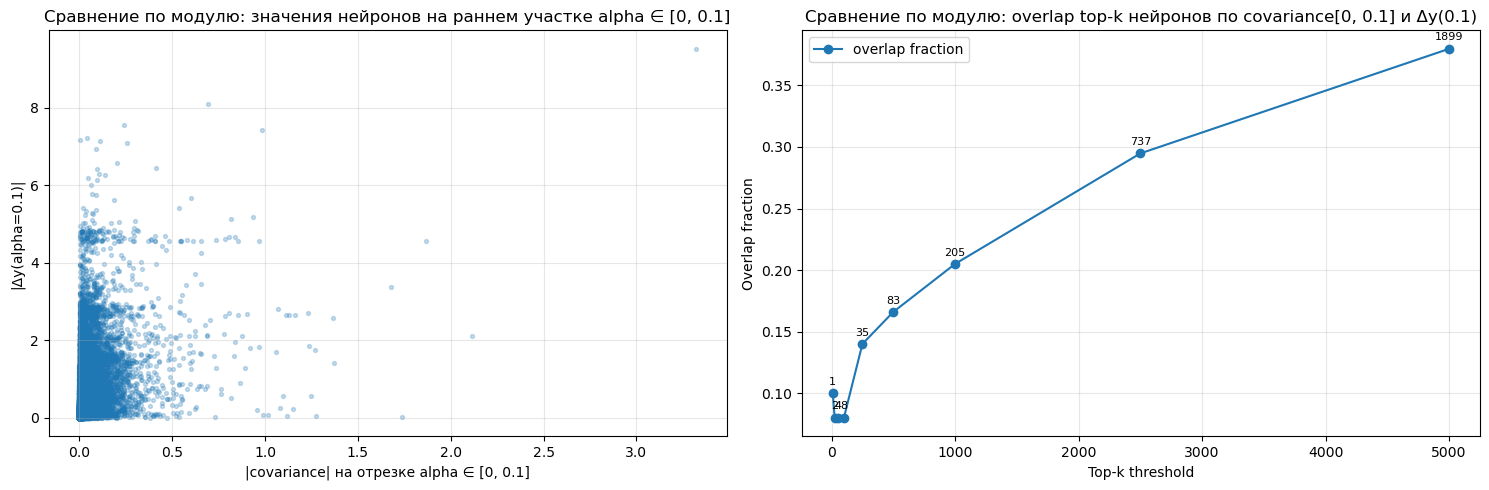

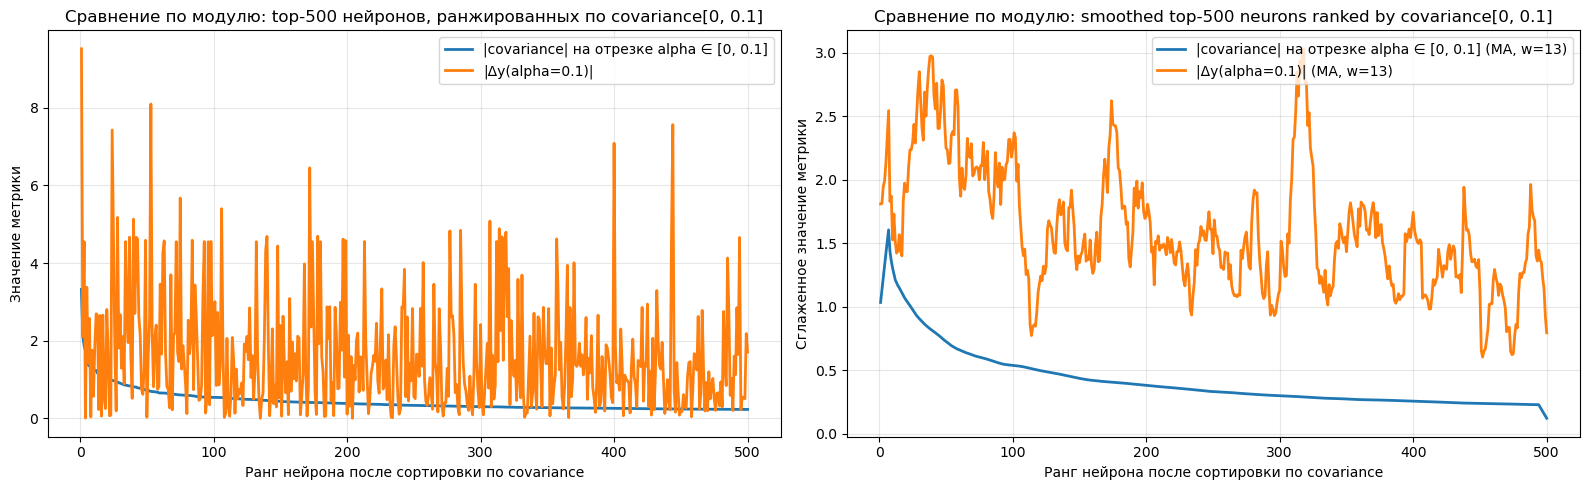

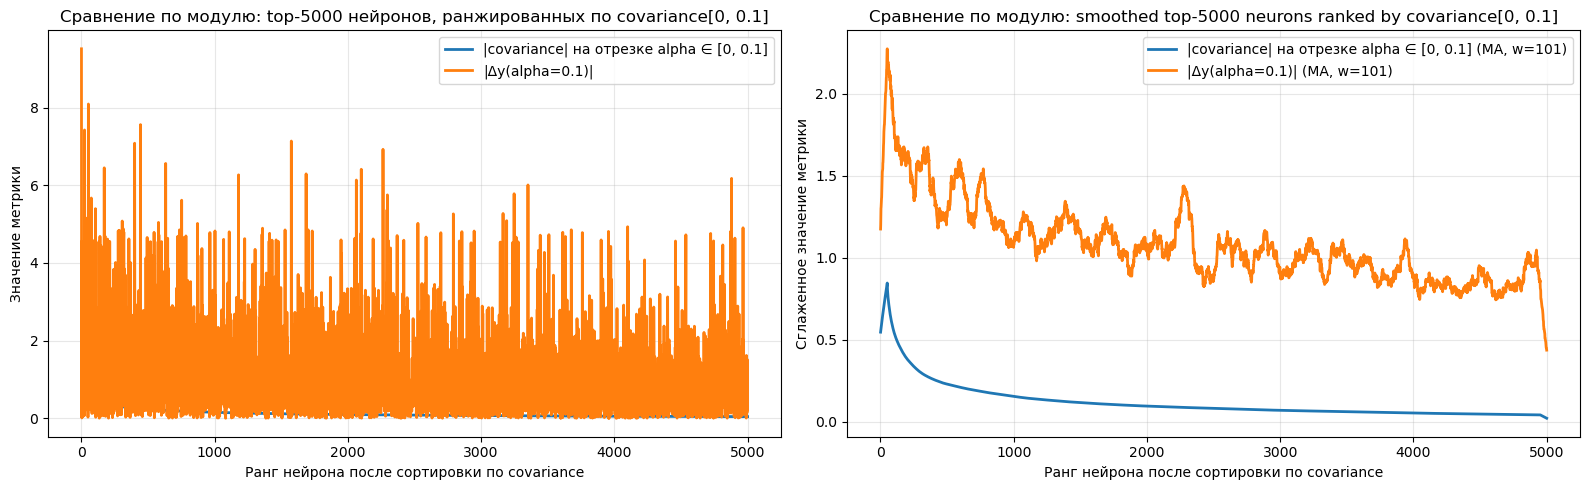

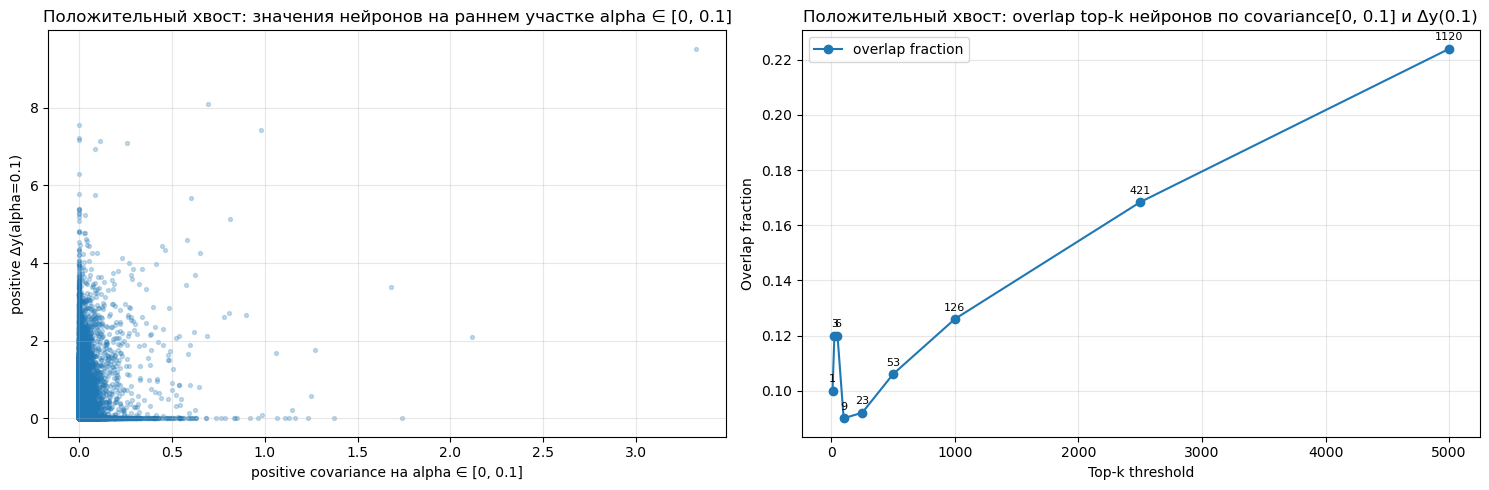

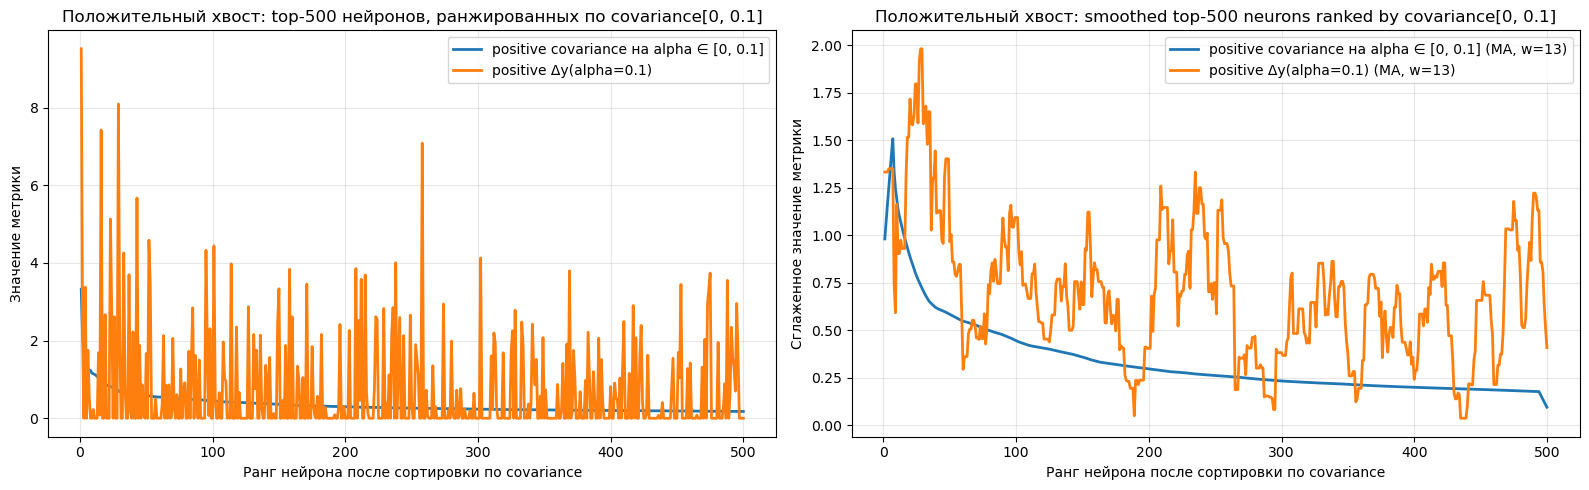

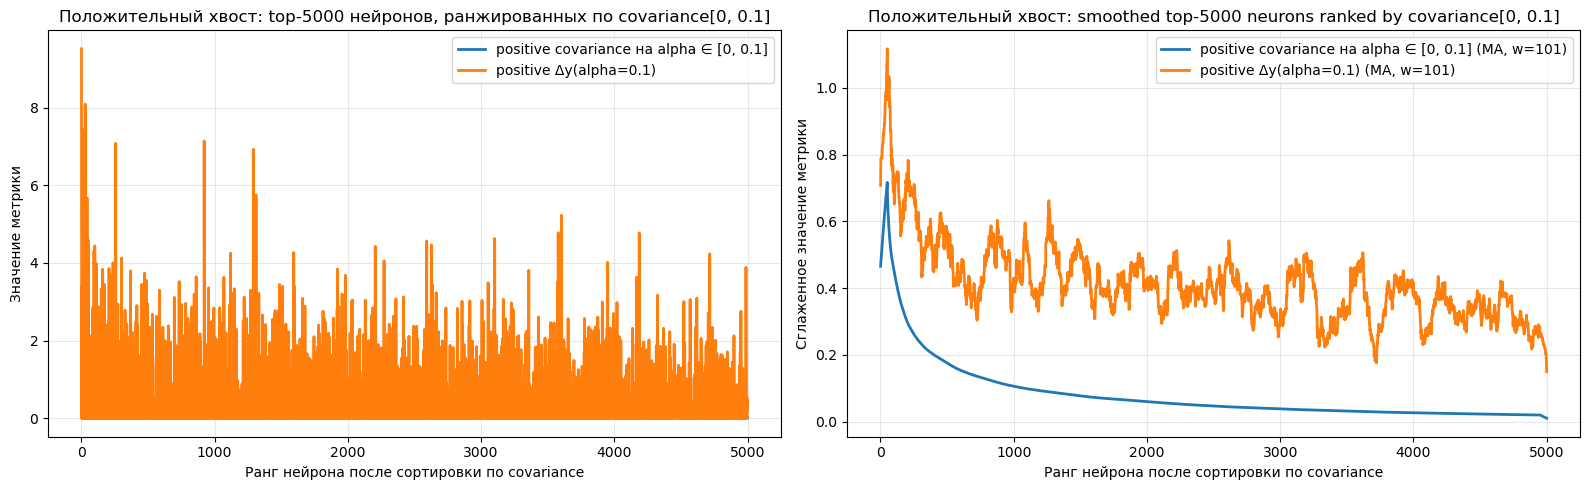

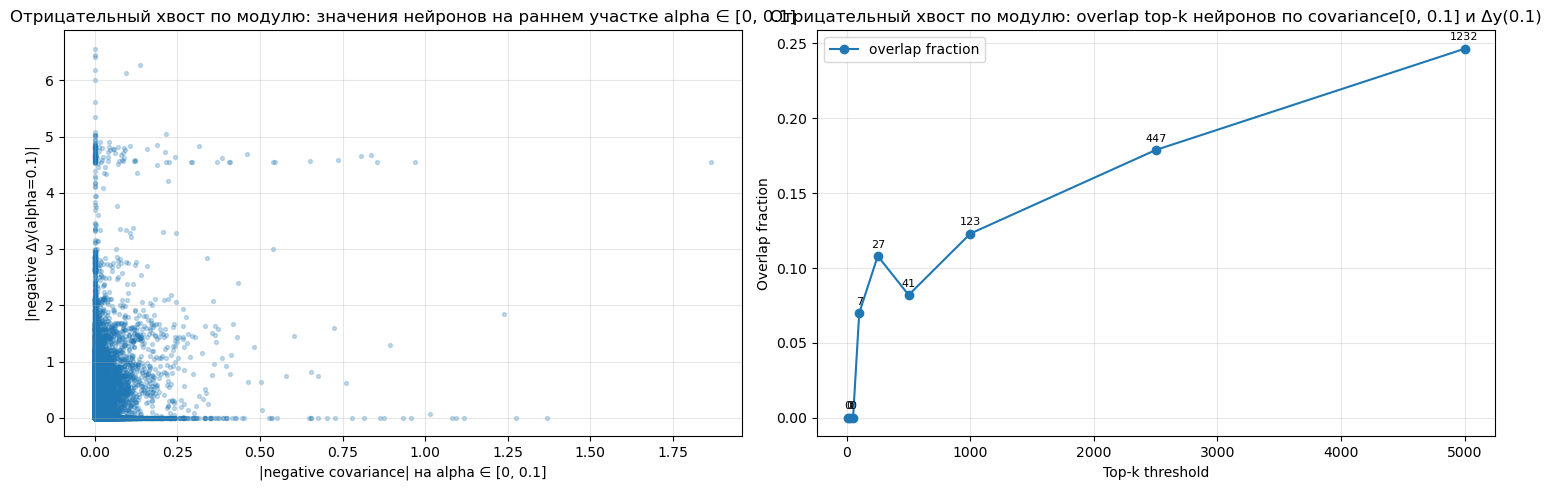

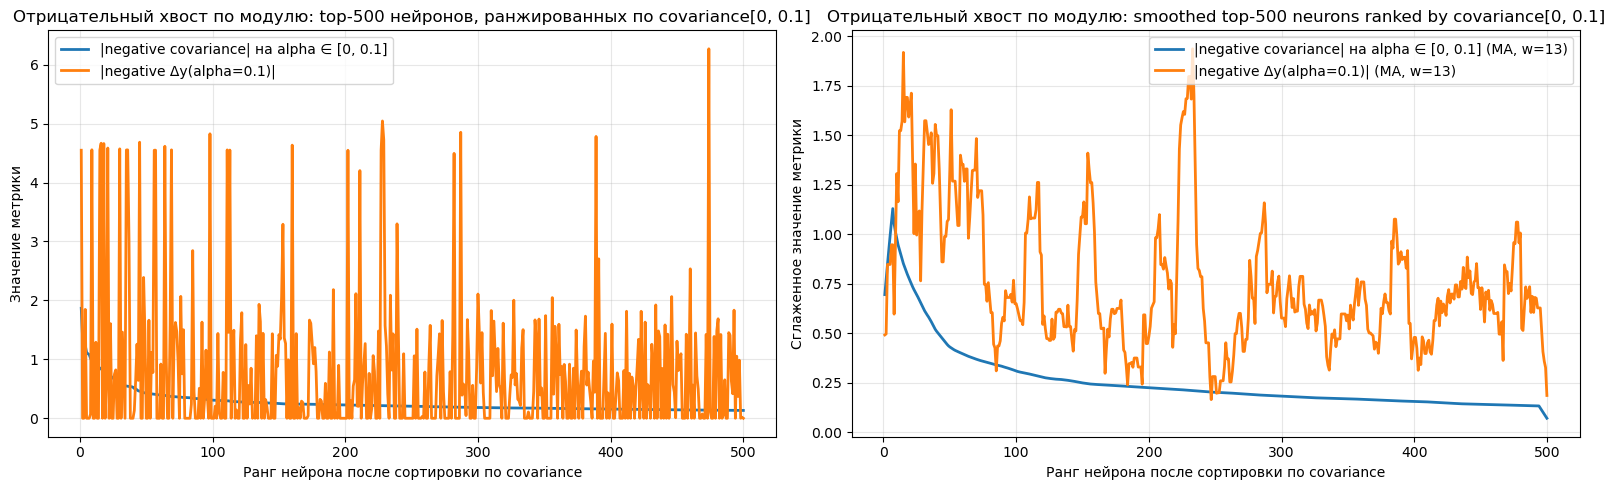

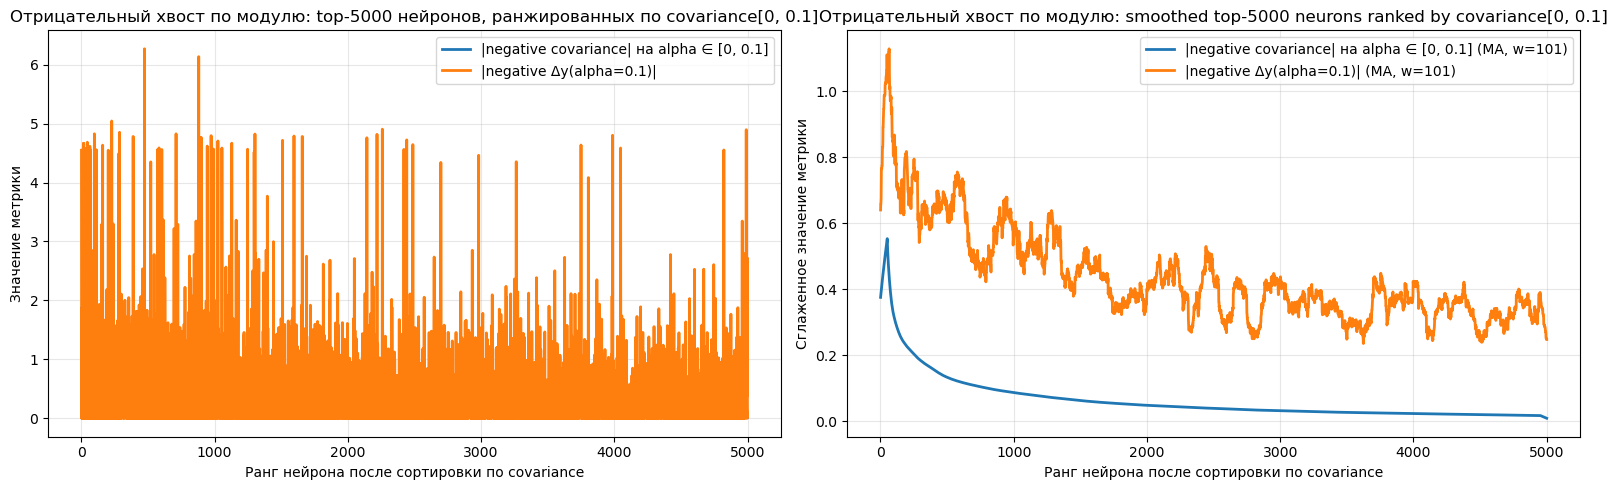

In [9]:
pairwise_focus_result = run_covariance_pairwise_alpha_focus(
    image_path="data/jess.jpg",
    layer_name="model.5",
    alpha_point=0.1,
    segment_steps=128,
    clear_every=8,
    requested_top_ks=(500, 5000),
    pair_names=("exact_attr", "delta_y"),
    mode_names=("abs", "positive", "negative"),
)
